# AI Car Insurance Advisor - Sprint 1 Evaluation Notebook


Summary
- product components included
- policy catalog preparation
- feature dictionary
- synthetic training and evaluation data used for the baseline
- model comparison for risk and premium prediction
- recommendation quality and safety checks
- feature importance
- latency and optional LLM evaluation
- presentation-ready charts for the demo

How to read the outputs:
- tables show the measured results
- charts show how the system behaves across important business views
- the final section gives a short interpretation for the demo

## 1. Why these models were selected



Why these models were used:
- Linear Regression gives a fast and interpretable regression baseline.
- Random Forest can capture non-linear behaviour without much tuning.
- Logistic Regression gives a simple baseline for cover-family prediction.
- Random Forest Classifier can capture interactions between profile features.

What to look for in the outputs:
- lower error is better for regression
- higher accuracy, precision, recall, and F1 are better for classification
- the selected model should balance performance and simplicity

In [28]:
# Import the libraries used throughout the evaluation notebook.
# The install command below is only needed in a fresh Colab runtime.

# !pip -q install pandas numpy scikit-learn matplotlib groq

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## 2. Product components

This table lists the main product pieces already available in Sprint 1.

What the output shows:
- each backend component
- its purpose in the system
- why it matters for the demo

This is useful in the presentation because it shows Sprint 1 is already a working backend, not just a model in isolation.

In [29]:
product_components = pd.DataFrame([
    {
        "Component": "Approved policy catalog",
        "Purpose": "Stores allowed insurer products and coverage attributes",
        "Sprint 1 Status": "Implemented",
        "Notes": "Recommendations are constrained to this catalog only",
    },
    {
        "Component": "Synthetic training data generator",
        "Purpose": "Bootstraps customer records for baseline training and evaluation",
        "Sprint 1 Status": "Implemented",
        "Notes": "Used because real labelled recommendation data is not yet available",
    },
    {
        "Component": "Risk score model",
        "Purpose": "Predicts driver risk score from profile and vehicle features",
        "Sprint 1 Status": "Implemented",
        "Notes": "Model selected through holdout evaluation",
    },
    {
        "Component": "Premium estimation model",
        "Purpose": "Predicts an expected portfolio premium",
        "Sprint 1 Status": "Implemented",
        "Notes": "Model selected through holdout evaluation",
    },
    {
        "Component": "Recommendation engine",
        "Purpose": "Ranks top approved policies using rules plus model outputs",
        "Sprint 1 Status": "Implemented",
        "Notes": "Top-3 recommendations generated from constrained catalog",
    },
    {
        "Component": "Manual review fallback",
        "Purpose": "Stops automated recommendation when required fields are missing",
        "Sprint 1 Status": "Implemented",
        "Notes": "Important for reliability and auditability",
    },
    {
        "Component": "LLM explanation layer",
        "Purpose": "Explains the recommendation in natural language",
        "Sprint 1 Status": "Optional",
        "Notes": "Evaluated separately with latency, tokens, and cost estimate",
    },
])

product_components

,Component,Purpose,Sprint 1 Status,Notes
0,Approved policy catalog,Stores allowed insurer products and coverage a...,Implemented,Recommendations are constrained to this catalo...
1,Synthetic training data generator,Bootstraps customer records for baseline train...,Implemented,Used because real labelled recommendation data...
2,Risk score model,Predicts driver risk score from profile and ve...,Implemented,Model selected through holdout evaluation
3,Premium estimation model,Predicts an expected portfolio premium,Implemented,Model selected through holdout evaluation
4,Recommendation engine,Ranks top approved policies using rules plus m...,Implemented,Top-3 recommendations generated from constrain...
5,Manual review fallback,Stops automated recommendation when required f...,Implemented,Important for reliability and auditability
6,LLM explanation layer,Explains the recommendation in natural language,Optional,"Evaluated separately with latency, tokens, and..."


## 3. Load and prepare the approved policy catalog

This section loads the approved insurance catalog used by the recommender.

What the code does:
- finds the uploaded CSV file
- loads it into a DataFrame
- standardises the main fields used later in the notebook

What the output means:
- the table preview confirms the catalog was loaded correctly
- the shape confirms how many products are available for recommendation
- this also proves recommendations are restricted to approved catalog items

In [30]:
# Load the approved product catalog that the recommender is allowed to use.

DATASET_FILENAME = "australian_car_insurance_policies_readable_headers.csv"

def locate_dataset(filename=DATASET_FILENAME):
    candidate_paths = [
        filename,
        f"/mnt/data/{filename}",
        f"/content/{filename}",
    ]
    for path in candidate_paths:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"Could not find {filename}. Upload the file or place it in the working directory.")

catalog_path = locate_dataset()
policy_catalog = pd.read_csv(catalog_path)

policy_catalog["Policy ID"] = policy_catalog["Policy ID"].astype(str)
policy_catalog["Insurer"] = policy_catalog["Insurer"].astype(str).str.strip()
policy_catalog["Product Name"] = policy_catalog["Product Name"].astype(str).str.strip()
policy_catalog["Cover Family"] = policy_catalog["Cover Family"].astype(str).str.strip().str.lower()
policy_catalog["State Specific"] = policy_catalog["State Specific"].fillna("General")

print(f"Catalog loaded from: {catalog_path}")
print(f"Catalog shape: {policy_catalog.shape}")
display(policy_catalog.head())

Catalog loaded from: australian_car_insurance_policies_readable_headers.csv
Catalog shape: (74, 11)


,Policy ID,Insurer,Product Name,Cover Family,Product Tier,State Specific,Own Vehicle Cover,Third Party Property Cover,Fire/Theft Cover,Injury Cover,Official URL
0,ALLIANZ_COMP,Allianz,Comprehensive Car Insurance,comprehensive,standard,general,yes,yes,yes,no,https://www.allianz.com.au/car-insurance/compr...
1,ALLIANZ_COMP_ESS,Allianz,Comprehensive Car Insurance Essentials,comprehensive,basics,general,yes,yes,yes,no,https://www.allianz.com.au/car-insurance/compr...
2,ALLIANZ_TPPD,Allianz,Third Party Property Damage Car Insurance,third_party_property_damage,standard,general,no,yes,no,no,https://www.allianz.com.au/car-insurance/third...
3,ALLIANZ_CTP_NSW,Allianz,CTP Insurance,ctp_or_mai,standard,NSW,no,no,no,yes,https://www.allianz.com.au/ctp-insurance/nsw.html
4,ALLIANZ_CTP_QLD,Allianz,CTP Insurance,ctp_or_mai,standard,QLD,no,no,no,yes,https://www.allianz.com.au/ctp-insurance/qld.html


In [31]:
import numpy as np
import pandas as pd

def yes_no_to_num(value):
    text = str(value).strip().lower()
    if text in {"yes", "y", "true", "1"}:
        return 1.0
    if text in {"partial", "limited"}:
        return 0.5
    return 0.0

# Standardise core text columns
policy_catalog["Policy ID"] = policy_catalog["Policy ID"].astype(str).str.strip()
policy_catalog["Insurer"] = policy_catalog["Insurer"].astype(str).str.strip()
policy_catalog["Product Name"] = policy_catalog["Product Name"].astype(str).str.strip()
policy_catalog["Cover Family"] = policy_catalog["Cover Family"].astype(str).str.strip().str.lower()
policy_catalog["Product Tier"] = policy_catalog["Product Tier"].astype(str).str.strip().str.lower()
policy_catalog["State Specific"] = policy_catalog["State Specific"].fillna("general").astype(str).str.strip()

# Create the cleaned state column expected by the recommendation code
policy_catalog["state_specific_clean"] = policy_catalog["State Specific"].str.lower().replace({
    "all": "general",
    "nationwide": "general"
})

# Convert cover flags to numeric scores
policy_catalog["Own Vehicle Cover"] = policy_catalog["Own Vehicle Cover"].apply(yes_no_to_num)
policy_catalog["Third Party Property Cover"] = policy_catalog["Third Party Property Cover"].apply(yes_no_to_num)
policy_catalog["Fire/Theft Cover"] = policy_catalog["Fire/Theft Cover"].apply(yes_no_to_num)
policy_catalog["Injury Cover"] = policy_catalog["Injury Cover"].apply(yes_no_to_num)

# Coverage score used in ranking
policy_catalog["coverage_score"] = (
    40 * policy_catalog["Own Vehicle Cover"]
    + 25 * policy_catalog["Third Party Property Cover"]
    + 20 * policy_catalog["Fire/Theft Cover"]
    + 15 * policy_catalog["Injury Cover"]
)

# Simple base premium hint used in premium estimation
cover_base_map = {
    "comprehensive": 1100,
    "third_party_fire_theft": 750,
    "third_party_property_damage": 520
}
tier_adjustment_map = {
    "basics": -120,
    "low_km": -90,
    "standard": 0,
    "plus": 140,
    "premium": 260
}

policy_catalog["base_premium_hint"] = (
    policy_catalog["Cover Family"].map(cover_base_map).fillna(700)
    + policy_catalog["Product Tier"].map(tier_adjustment_map).fillna(0)
)

print("Prepared policy catalog columns:")
display(policy_catalog[[
    "Policy ID",
    "Insurer",
    "Product Name",
    "Cover Family",
    "Product Tier",
    "State Specific",
    "state_specific_clean",
    "coverage_score",
    "base_premium_hint"
]].head())

Prepared policy catalog columns:


,Policy ID,Insurer,Product Name,Cover Family,Product Tier,State Specific,state_specific_clean,coverage_score,base_premium_hint
0,ALLIANZ_COMP,Allianz,Comprehensive Car Insurance,comprehensive,standard,general,general,85.0,1100.0
1,ALLIANZ_COMP_ESS,Allianz,Comprehensive Car Insurance Essentials,comprehensive,basics,general,general,85.0,980.0
2,ALLIANZ_TPPD,Allianz,Third Party Property Damage Car Insurance,third_party_property_damage,standard,general,general,25.0,520.0
3,ALLIANZ_CTP_NSW,Allianz,CTP Insurance,ctp_or_mai,standard,NSW,nsw,15.0,700.0
4,ALLIANZ_CTP_QLD,Allianz,CTP Insurance,ctp_or_mai,standard,QLD,qld,15.0,700.0


## 4. Feature catalog and dictionary

This section documents the customer-side features used by the Sprint 1 backend.

What the output shows:
- feature name
- data type
- business meaning
- where the value comes from

This table is useful in the demo because it explains what the model is actually using.

In [32]:
feature_dictionary = pd.DataFrame([
    ["age", "numeric", "Driver age in years", "Manual input or extracted"],
    ["years_licensed", "numeric", "Years since the driver became licensed", "Derived / manual"],
    ["state", "categorical", "Australian state / territory", "Manual input or extracted"],
    ["vehicle_type", "categorical", "Vehicle segment such as sedan, SUV, electric, luxury", "Manual input / extracted"],
    ["usage_type", "categorical", "Primary usage pattern such as private, commute, business, rideshare", "Manual input"],
    ["parking_type", "categorical", "Main parking arrangement", "Manual input"],
    ["vehicle_year", "numeric", "Manufacture year of the vehicle", "Manual input / extracted"],
    ["vehicle_age", "numeric", "Age of the vehicle in years", "Derived"],
    ["vehicle_value", "numeric", "Vehicle value or sum insured", "Manual input / extracted"],
    ["annual_km", "numeric", "Estimated annual kilometres driven", "Manual input"],
    ["claims_last_5y", "numeric", "Number of claims in the last 5 years", "Manual input / extracted"],
    ["at_fault_claims", "numeric", "Number of at-fault claims", "Manual input / extracted"],
    ["incidents_last_3y", "numeric", "Recent traffic incidents", "Manual input"],
    ["licence_suspensions", "numeric", "Suspensions on the driver's licence", "Manual input"],
    ["no_claim_years", "numeric", "Years with no claims", "Manual input / extracted"],
    ["has_security", "binary", "Whether the car has security / secure parking", "Manual input / extracted"],
    ["young_driver", "binary", "Flag for drivers under 25", "Derived"],
    ["budget_preference", "categorical", "Declared budget sensitivity", "Manual input"],
    ["cover_preference", "categorical", "Preferred cover style such as basic / balanced / premium", "Manual input"],
], columns=["Feature", "Type", "Meaning", "Source"])

feature_dictionary

,Feature,Type,Meaning,Source
0,age,numeric,Driver age in years,Manual input or extracted
1,years_licensed,numeric,Years since the driver became licensed,Derived / manual
2,state,categorical,Australian state / territory,Manual input or extracted
3,vehicle_type,categorical,"Vehicle segment such as sedan, SUV, electric, ...",Manual input / extracted
4,usage_type,categorical,"Primary usage pattern such as private, commute...",Manual input
5,parking_type,categorical,Main parking arrangement,Manual input
6,vehicle_year,numeric,Manufacture year of the vehicle,Manual input / extracted
7,vehicle_age,numeric,Age of the vehicle in years,Derived
8,vehicle_value,numeric,Vehicle value or sum insured,Manual input / extracted
9,annual_km,numeric,Estimated annual kilometres driven,Manual input


## 5. Create the synthetic training and evaluation dataset

Sprint 1 uses a synthetic dataset to bootstrap the backend and test the full flow before richer real-world data is added.

What the code does:
- generates realistic customer profiles
- creates target labels for risk, premium, and cover family
- prepares data for model training and evaluation

What the output means:
- the preview shows the generated customer records
- the dataset shape shows the baseline has enough rows to test the pipeline meaningfully

In [33]:
# Generate a synthetic customer dataset for model training and evaluation.

STATES = ["NSW", "VIC", "QLD", "WA", "SA", "ACT", "TAS", "NT"]
VEHICLE_TYPES = ["sedan", "suv", "hatch", "ute", "electric", "luxury", "sports"]
USAGE_TYPES = ["private", "commute", "business", "rideshare"]
PARKING_TYPES = ["garage", "street", "carport"]
COVER_PREFS = ["basic", "balanced", "premium"]

def generate_synthetic_customers(n=3000, seed=42):
    rng = np.random.default_rng(seed)
    rows = []

    for i in range(n):
        age = int(rng.integers(18, 80))
        years_licensed = max(0, age - 17 - int(rng.integers(0, 6)))

        state = rng.choice(
            STATES,
            p=np.array([0.31, 0.25, 0.20, 0.10, 0.06, 0.03, 0.03, 0.02]),
        )

        vehicle_type = rng.choice(
            VEHICLE_TYPES,
            p=np.array([0.26, 0.24, 0.14, 0.12, 0.08, 0.08, 0.08]),
        )
        usage_type = rng.choice(
            USAGE_TYPES,
            p=np.array([0.42, 0.35, 0.15, 0.08]),
        )
        parking_type = rng.choice(
            PARKING_TYPES,
            p=np.array([0.50, 0.30, 0.20]),
        )

        vehicle_year = int(rng.integers(2003, 2026))
        vehicle_age = 2026 - vehicle_year

        annual_km = int(np.clip(rng.normal(14000, 6000), 3000, 40000))
        vehicle_value = float(np.clip(rng.normal(24000, 14000), 4000, 90000))
        if vehicle_type in ["electric", "luxury", "sports"]:
            vehicle_value *= float(rng.uniform(1.2, 1.8))

        claims_last_5y = int(
            np.clip(
                rng.poisson(
                    0.35 + (age < 25) * 0.45 + (usage_type in ["business", "rideshare"]) * 0.25
                ),
                0,
                6,
            )
        )
        at_fault_claims = int(
            np.clip(
                rng.binomial(claims_last_5y, 0.60) if claims_last_5y > 0 else 0,
                0,
                6,
            )
        )
        incidents_last_3y = int(
            np.clip(
                rng.poisson(0.25 + (age < 25) * 0.40 + (usage_type == "rideshare") * 0.35),
                0,
                5,
            )
        )
        licence_suspensions = int(
            rng.binomial(1, 0.02 + 0.04 * (age < 23) + 0.03 * (usage_type == "rideshare"))
        )
        no_claim_years = max(0, min(10, int(rng.integers(0, 11)) - claims_last_5y))
        has_security = int(rng.binomial(1, 0.65 if parking_type == "garage" else 0.35))
        young_driver = int(age < 25)

        budget_preference = rng.choice(["low", "medium", "high"], p=np.array([0.34, 0.45, 0.21]))
        cover_preference = rng.choice(COVER_PREFS, p=np.array([0.28, 0.48, 0.24]))

        risk_score = (
            25
            + 18 * young_driver
            + 6 * (usage_type in ["business", "rideshare"])
            + 7 * (usage_type == "rideshare")
            + 5 * (parking_type == "street")
            + 4 * claims_last_5y
            + 5 * at_fault_claims
            + 3 * incidents_last_3y
            + 15 * licence_suspensions
            + 0.00018 * vehicle_value
            + 0.00070 * annual_km
            + 4 * (vehicle_type in ["luxury", "sports"])
            - 1.4 * min(no_claim_years, 8)
            - 3 * has_security
        )
        if cover_preference == "premium":
            risk_score += 1.5

        risk_score = float(np.clip(risk_score + rng.normal(0, 4), 5, 98))

        if vehicle_value >= 30000 or vehicle_age <= 6 or cover_preference == "premium":
            preferred_cover_family = "comprehensive"
        elif vehicle_value >= 12000 or claims_last_5y == 0 or cover_preference == "balanced":
            preferred_cover_family = "third_party_fire_theft"
        else:
            preferred_cover_family = "third_party_property_damage"

        budget_factor = {"low": 0.90, "medium": 1.00, "high": 1.12}[budget_preference]
        usage_factor = {"private": 1.00, "commute": 1.05, "business": 1.12, "rideshare": 1.22}[usage_type]
        type_factor = {
            "sedan": 1.00,
            "suv": 1.07,
            "hatch": 0.95,
            "ute": 1.03,
            "electric": 1.12,
            "luxury": 1.22,
            "sports": 1.28,
        }[vehicle_type]
        cover_factor = {
            "third_party_property_damage": 0.72,
            "third_party_fire_theft": 0.88,
            "comprehensive": 1.00,
        }[preferred_cover_family]

        base = 250 + 10 * risk_score + 0.012 * vehicle_value + 0.010 * annual_km
        expected_premium = base * usage_factor * type_factor * budget_factor * cover_factor
        expected_premium = float(np.clip(expected_premium + rng.normal(0, 120), 350, 6500))

        rows.append(
            {
                "customer_id": f"CUST_{i:05d}",
                "age": age,
                "years_licensed": years_licensed,
                "state": state,
                "vehicle_type": vehicle_type,
                "usage_type": usage_type,
                "parking_type": parking_type,
                "vehicle_year": vehicle_year,
                "vehicle_age": vehicle_age,
                "vehicle_value": round(vehicle_value, 2),
                "annual_km": annual_km,
                "claims_last_5y": claims_last_5y,
                "at_fault_claims": at_fault_claims,
                "incidents_last_3y": incidents_last_3y,
                "licence_suspensions": licence_suspensions,
                "no_claim_years": no_claim_years,
                "has_security": has_security,
                "young_driver": young_driver,
                "budget_preference": budget_preference,
                "cover_preference": cover_preference,
                "preferred_cover_family": preferred_cover_family,
                "risk_score_target": round(risk_score, 2),
                "expected_premium_target": round(expected_premium, 2),
            }
        )

    return pd.DataFrame(rows)

synthetic_customers = generate_synthetic_customers(n=3000, seed=42)
print("Synthetic dataset shape:", synthetic_customers.shape)
synthetic_customers.head()

Synthetic dataset shape: (3000, 23)


,customer_id,age,years_licensed,state,vehicle_type,usage_type,parking_type,vehicle_year,vehicle_age,vehicle_value,annual_km,claims_last_5y,at_fault_claims,incidents_last_3y,licence_suspensions,no_claim_years,has_security,young_driver,budget_preference,cover_preference,preferred_cover_family,risk_score_target,expected_premium_target
0,CUST_00000,23,2,VIC,luxury,commute,garage,2015,11,24991.63,14767,1,0,2,0,9,1,1,low,premium,comprehensive,58.94,1461.51
1,CUST_00001,61,42,TAS,luxury,business,garage,2011,15,47937.91,16192,2,1,0,0,3,1,0,medium,basic,comprehensive,63.37,2303.89
2,CUST_00002,27,6,QLD,suv,business,carport,2022,4,36200.00,15312,0,0,0,0,4,1,0,medium,balanced,comprehensive,38.36,1406.89
3,CUST_00003,49,29,NSW,sedan,commute,garage,2022,4,26278.54,11990,0,0,0,0,6,1,0,medium,basic,comprehensive,25.96,838.98
4,CUST_00004,20,2,NSW,suv,private,street,2005,21,32758.27,14951,0,0,1,0,6,0,1,medium,balanced,comprehensive,57.08,1460.40


## 6. Train and compare the risk and premium models

This section trains the candidate models and compares them on the held-out test set.

What to look for:
- the best regression model should have lower MAE and RMSE
- a stronger R² means the model explains more variation in the target
- the chosen baseline should be accurate enough for Sprint 1 while still being simple

In [34]:
feature_cols = [
    "age",
    "years_licensed",
    "state",
    "vehicle_type",
    "usage_type",
    "parking_type",
    "vehicle_year",
    "vehicle_age",
    "vehicle_value",
    "annual_km",
    "claims_last_5y",
    "at_fault_claims",
    "incidents_last_3y",
    "licence_suspensions",
    "no_claim_years",
    "has_security",
    "young_driver",
    "budget_preference",
    "cover_preference",
]

numeric_cols = [c for c in feature_cols if synthetic_customers[c].dtype != "object"]
categorical_cols = [c for c in feature_cols if synthetic_customers[c].dtype == "object"]

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )

candidate_factories = {
    "Linear Regression": lambda: LinearRegression(),
    "Random Forest": lambda: RandomForestRegressor(
        n_estimators=180,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": lambda: GradientBoostingRegressor(
        random_state=42,
        n_estimators=180,
        learning_rate=0.05,
        max_depth=3,
    ),
}

def regression_metrics_df(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))) * 100,
    }

def evaluate_regression_candidates(X_train, X_test, y_train, y_test):
    metric_rows = []
    fitted_models = {}

    for name, factory in candidate_factories.items():
        model = Pipeline(
            steps=[
                ("prep", make_preprocessor()),
                ("model", factory()),
            ]
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        fitted_models[name] = model

        row = {"Model": name}
        row.update(regression_metrics_df(y_test, pred))
        metric_rows.append(row)

    metrics_df = (
        pd.DataFrame(metric_rows)
        .sort_values(["RMSE", "MAE", "MAPE", "R2"], ascending=[True, True, True, False])
        .reset_index(drop=True)
    )
    return metrics_df, fitted_models

X = synthetic_customers[feature_cols]
y_risk = synthetic_customers["risk_score_target"]
y_premium = synthetic_customers["expected_premium_target"]
y_cover = synthetic_customers["preferred_cover_family"]

X_train, X_test, y_risk_train, y_risk_test, y_premium_train, y_premium_test, y_cover_train, y_cover_test = train_test_split(
    X,
    y_risk,
    y_premium,
    y_cover,
    test_size=0.20,
    random_state=42,
    stratify=y_cover,
)

risk_metrics, risk_models = evaluate_regression_candidates(X_train, X_test, y_risk_train, y_risk_test)
premium_metrics, premium_models = evaluate_regression_candidates(X_train, X_test, y_premium_train, y_premium_test)

selected_risk_model_name = risk_metrics.iloc[0]["Model"]
selected_premium_model_name = premium_metrics.iloc[0]["Model"]

risk_model = risk_models[selected_risk_model_name]
premium_model = premium_models[selected_premium_model_name]

print("Selected risk model   :", selected_risk_model_name)
print("Selected premium model:", selected_premium_model_name)

Selected risk model   : Linear Regression
Selected premium model: Linear Regression


In [35]:
print("Risk model comparison")
display(risk_metrics.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "R2": "{:.3f}", "MAPE": "{:.2f}"}))

print("Premium model comparison")
display(premium_metrics.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "R2": "{:.3f}", "MAPE": "{:.2f}"}))

Risk model comparison


,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,3.107,3.924,0.913,7.98
1,Gradient Boosting,3.472,4.381,0.891,8.74
2,Random Forest,4.398,5.672,0.818,10.72


Premium model comparison


,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,120.834,150.994,0.878,10.75
1,Gradient Boosting,124.364,157.803,0.867,10.77
2,Random Forest,147.243,193.999,0.798,12.52


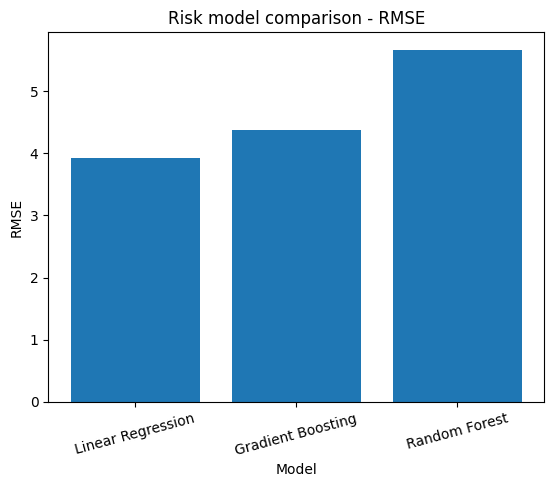

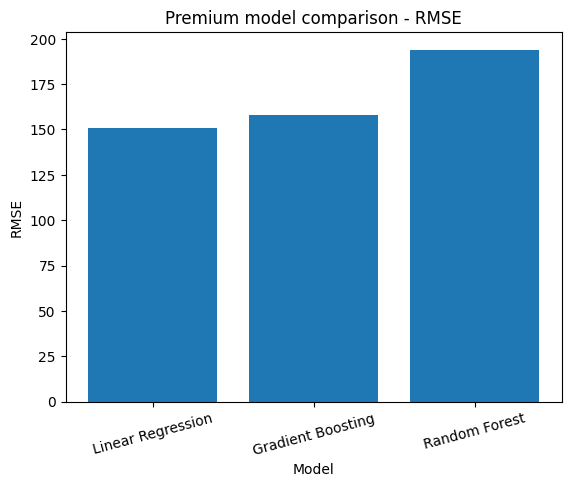

In [36]:
fig, ax = plt.subplots()
ax.bar(risk_metrics["Model"], risk_metrics["RMSE"])
ax.set_title("Risk model comparison - RMSE")
ax.set_ylabel("RMSE")
ax.set_xlabel("Model")
plt.xticks(rotation=15)
plt.show()

fig, ax = plt.subplots()
ax.bar(premium_metrics["Model"], premium_metrics["RMSE"])
ax.set_title("Premium model comparison - RMSE")
ax.set_ylabel("RMSE")
ax.set_xlabel("Model")
plt.xticks(rotation=15)
plt.show()

## 7. Selected-model performance visuals

These plots show how the chosen models behave on the test set.

What the outputs mean:
- points close to the diagonal indicate better predictions
- smaller residual spread indicates more stable error
- the premium plot is especially useful for explaining practical business accuracy

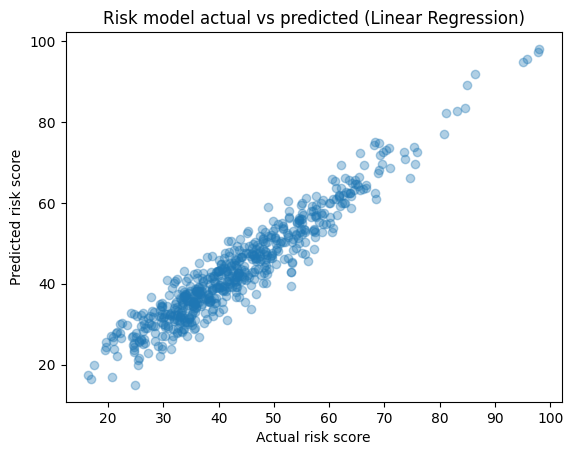

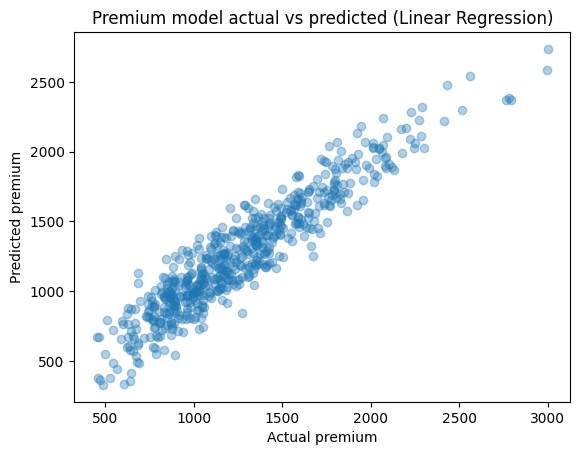

In [37]:
risk_pred = risk_model.predict(X_test)
premium_pred = premium_model.predict(X_test)

fig, ax = plt.subplots()
ax.scatter(y_risk_test, risk_pred, alpha=0.35)
ax.set_title(f"Risk model actual vs predicted ({selected_risk_model_name})")
ax.set_xlabel("Actual risk score")
ax.set_ylabel("Predicted risk score")
plt.show()

fig, ax = plt.subplots()
ax.scatter(y_premium_test, premium_pred, alpha=0.35)
ax.set_title(f"Premium model actual vs predicted ({selected_premium_model_name})")
ax.set_xlabel("Actual premium")
ax.set_ylabel("Predicted premium")
plt.show()

## 8. Feature importance

This section shows which features influenced the selected models the most.

What the output means:
- larger importance values indicate a stronger contribution
- for tree models, this is based on feature importance
- for linear models, this is based on coefficient magnitude

This helps explain whether the model behaviour looks reasonable from an insurance perspective.

In [38]:
def get_model_feature_importance(model_pipeline: Pipeline, top_n: int = 12) -> pd.DataFrame:
    model = model_pipeline.named_steps["model"]
    prep = model_pipeline.named_steps["prep"]
    feature_names = prep.get_feature_names_out()

    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    elif hasattr(model, "coef_"):
        values = np.abs(np.ravel(model.coef_))
    else:
        raise ValueError("Selected model does not expose feature importances or coefficients.")

    out = (
        pd.DataFrame({"feature": feature_names, "importance": values})
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    out["feature"] = (
        out["feature"]
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
    )
    return out

risk_importance = get_model_feature_importance(risk_model, top_n=12)
premium_importance = get_model_feature_importance(premium_model, top_n=12)

print("Top drivers of the risk model")
display(risk_importance)

print("Top drivers of the premium model")
display(premium_importance)

Top drivers of the risk model


,feature,importance
0,usage_type_rideshare,7.831592
1,young_driver,5.812807
2,usage_type_commute,4.702828
3,usage_type_private,4.565500
4,no_claim_years,4.258712
5,annual_km,3.891576
6,parking_type_street,3.415377
7,vehicle_value,3.009647
8,vehicle_type_sports,2.958943
9,at_fault_claims,2.839295


Top drivers of the premium model


,feature,importance
0,vehicle_value,278.992743
1,vehicle_type_sports,274.032940
2,usage_type_rideshare,252.282499
3,vehicle_type_luxury,183.329091
4,vehicle_type_hatch,178.981059
5,usage_type_private,173.892541
6,budget_preference_high,142.724519
7,budget_preference_low,136.899855
8,vehicle_type_sedan,125.882491
9,usage_type_commute,111.433093


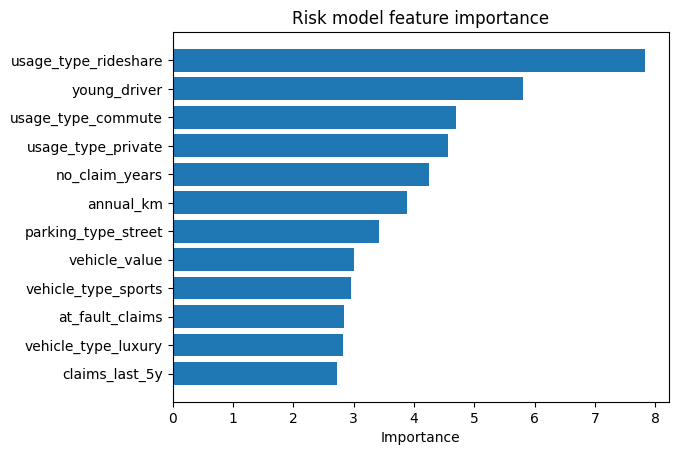

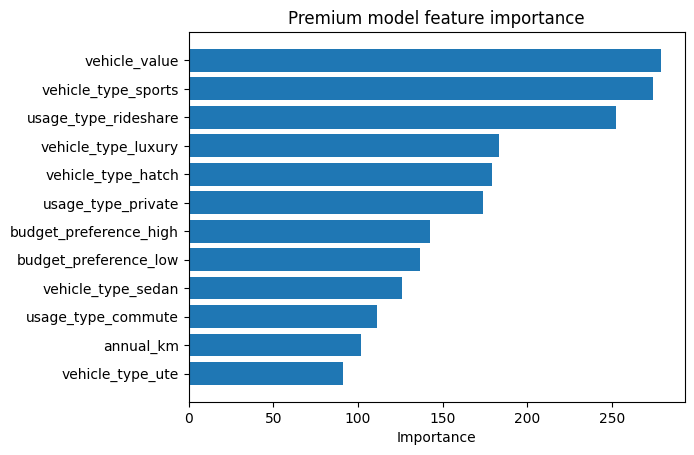

In [39]:
fig, ax = plt.subplots()
ax.barh(risk_importance["feature"][::-1], risk_importance["importance"][::-1])
ax.set_title("Risk model feature importance")
ax.set_xlabel("Importance")
plt.show()

fig, ax = plt.subplots()
ax.barh(premium_importance["feature"][::-1], premium_importance["importance"][::-1])
ax.set_title("Premium model feature importance")
ax.set_xlabel("Importance")
plt.show()

## 9. Rebuild the recommendation pipeline for evaluation

This section recreates the Sprint 1 recommendation logic in notebook form so the backend can be evaluated end to end.

What the code does:
- validates profile inputs
- normalises the profile fields
- predicts risk and premium
- recommends a cover family
- ranks policies from the approved catalog

What the output means:
- later sections use this pipeline to test recommendation quality and safety behaviour

In [40]:
# Define the evaluation version of the recommendation pipeline used in Sprint 1.

REQUIRED_FIELDS = [
    "age",
    "state",
    "vehicle_year",
    "vehicle_value",
    "annual_km",
    "claims_last_5y",
    "vehicle_type",
    "usage_type",
]

def parse_bool(value):
    if isinstance(value, bool):
        return int(value)
    if value is None:
        return 0
    return int(str(value).strip().lower() in {"1", "true", "yes", "y"})

def validate_user_profile(profile: dict) -> dict:
    missing_fields = [f for f in REQUIRED_FIELDS if f not in profile or profile[f] in [None, ""]]
    return {
        "is_valid": len(missing_fields) == 0,
        "missing_fields": missing_fields,
    }

def normalize_user_profile(profile: dict) -> dict:
    p = dict(profile)

    p["state"] = str(p.get("state", "NSW")).upper()
    p["vehicle_type"] = str(p.get("vehicle_type", "sedan")).lower()
    p["usage_type"] = str(p.get("usage_type", "private")).lower()
    p["parking_type"] = str(p.get("parking_type", "garage")).lower()
    p["budget_preference"] = str(p.get("budget_preference", "medium")).lower()
    p["cover_preference"] = str(p.get("cover_preference", "balanced")).lower()

    p["age"] = int(float(p.get("age", 30)))
    p["vehicle_year"] = int(float(p.get("vehicle_year", 2018)))
    p["vehicle_age"] = int(float(p.get("vehicle_age", 2026 - p["vehicle_year"])))
    p["years_licensed"] = int(float(p.get("years_licensed", max(0, p["age"] - 18))))
    p["vehicle_value"] = float(p.get("vehicle_value", 20000))
    p["annual_km"] = int(float(p.get("annual_km", 12000)))

    for col in ["claims_last_5y", "at_fault_claims", "incidents_last_3y", "licence_suspensions", "no_claim_years"]:
        p[col] = int(float(p.get(col, 0)))

    p["has_security"] = parse_bool(p.get("has_security", 0))
    p["young_driver"] = int(p["age"] < 25)

    return p

def recommend_cover_family(profile: dict, risk_score: float) -> str:
    if (
        profile["vehicle_value"] >= 28000
        or profile["vehicle_age"] <= 6
        or risk_score >= 58
        or profile["cover_preference"] == "premium"
    ):
        return "comprehensive"

    if (
        profile["vehicle_value"] >= 12000
        or risk_score >= 38
        or profile["cover_preference"] == "balanced"
    ):
        return "third_party_fire_theft"

    return "third_party_property_damage"

def estimate_policy_premium(profile: dict, policy_row: pd.Series, risk_score: float) -> float:
    state_factor = 1.06 if profile["state"] in ["NSW", "VIC", "QLD"] else 1.00
    age_factor = 1.18 if profile["age"] < 25 else (0.97 if profile["age"] > 60 else 1.00)
    claims_factor = 1 + 0.08 * profile["claims_last_5y"] + 0.05 * profile["at_fault_claims"]
    km_factor = 1 + max(profile["annual_km"] - 12000, 0) / 100000
    usage_factor = {
        "private": 1.00,
        "commute": 1.04,
        "business": 1.12,
        "rideshare": 1.24,
    }.get(profile["usage_type"], 1.00)
    value_factor = 1 + profile["vehicle_value"] / 150000

    premium = (
        policy_row["base_premium_hint"]
        * (0.65 + risk_score / 100)
        * state_factor
        * age_factor
        * claims_factor
        * km_factor
        * usage_factor
        * value_factor
    )
    return float(np.clip(premium, 180, 8000))

def score_policy_fit(profile: dict, policy_row: pd.Series, recommended_cover: str, risk_score: float):
    eligible = (
        policy_row["state_specific_clean"] == "general"
        or policy_row["state_specific_clean"] == profile["state"]
    )
    if not eligible:
        return -1e9, None

    score = 0.0

    if policy_row["Cover Family"] == recommended_cover:
        score += 35
    elif recommended_cover == "comprehensive" and policy_row["Cover Family"] == "third_party_fire_theft":
        score += 10
    elif recommended_cover == "third_party_fire_theft" and policy_row["Cover Family"] == "third_party_property_damage":
        score += 8

    if profile["vehicle_value"] >= 25000 and policy_row["Own Vehicle Cover"] >= 1:
        score += 18

    if profile["claims_last_5y"] == 0 and policy_row["Fire/Theft Cover"] >= 0.5:
        score += 10

    if risk_score >= 55 and str(policy_row["Product Tier"]).lower() in ["standard", "plus", "premium"]:
        score += 8

    if profile["budget_preference"] == "low" and str(policy_row["Product Tier"]).lower() in ["basics", "low_km", "standard"]:
        score += 12

    if profile["budget_preference"] == "high" and str(policy_row["Product Tier"]).lower() in ["plus", "premium"]:
        score += 12

    if profile["annual_km"] <= 10000 and str(policy_row["Product Tier"]).lower() == "low_km":
        score += 15

    predicted_policy_premium = estimate_policy_premium(profile, policy_row, risk_score)
    budget_cap = {"low": 1300, "medium": 2200, "high": 3500}[profile["budget_preference"]]

    if predicted_policy_premium <= budget_cap:
        score += 12
    else:
        score -= min((predicted_policy_premium - budget_cap) / 120, 18)

    score += policy_row["coverage_score"] / 8.0
    return score, predicted_policy_premium

def recommend_policies(profile: dict, catalog: pd.DataFrame, risk_score: float, top_k: int = 3):
    recommended_cover = recommend_cover_family(profile, risk_score)
    rows = []

    for _, row in catalog.iterrows():
        fit_score, estimated_premium = score_policy_fit(profile, row, recommended_cover, risk_score)
        if fit_score < -1e8:
            continue

        rows.append(
            {
                "Policy ID": row["Policy ID"],
                "Insurer": row["Insurer"],
                "Product Name": row["Product Name"],
                "Cover Family": row["Cover Family"],
                "Product Tier": row["Product Tier"],
                "State Specific": row["State Specific"],
                "Estimated Premium": round(float(estimated_premium), 2),
                "Fit Score": round(float(fit_score), 2),
            }
        )

    ranked = (
        pd.DataFrame(rows)
        .sort_values(["Fit Score", "Estimated Premium"], ascending=[False, True])
        .head(top_k)
        .reset_index(drop=True)
    )
    return ranked, recommended_cover

def run_advisor_pipeline(manual_profile: dict, catalog: pd.DataFrame = policy_catalog, top_k: int = 3):
    validation = validate_user_profile(manual_profile)

    if not validation["is_valid"]:
        return {
            "status": "manual_review",
            "missing_fields": validation["missing_fields"],
        }

    normalized_profile = normalize_user_profile(manual_profile)
    model_input = pd.DataFrame([normalized_profile])[feature_cols]

    predicted_risk_score = float(risk_model.predict(model_input)[0])
    predicted_portfolio_premium = float(premium_model.predict(model_input)[0])

    recommendations, recommended_cover = recommend_policies(
        profile=normalized_profile,
        catalog=catalog,
        risk_score=predicted_risk_score,
        top_k=top_k,
    )

    return {
        "status": "ok",
        "risk_score": round(predicted_risk_score, 2),
        "portfolio_premium_estimate": round(predicted_portfolio_premium, 2),
        "recommended_cover_family": recommended_cover,
        "recommendations": recommendations,
    }

## 10. Recommendation evaluation

The recommender is partly model-based and partly rules-based, so the evaluation needs to check more than one thing.

What is measured here:
- cover-family accuracy
- macro precision, recall, and F1
- top-1 and top-3 family match
- catalog compliance
- state eligibility
- runtime

Why this matters:
- it checks whether the recommender is correct
- it checks whether the shortlist is useful
- it checks whether the system stays within business rules

In [41]:
# Evaluate the recommendation pipeline on a held-out sample and compute the main recommendation metrics.

eval_sample = (
    X_test
    .join(y_cover_test.rename("true_cover_family"))
    .sample(n=min(200, len(X_test)), random_state=42)
    .reset_index(drop=True)
)

recommendation_rows = []
latency_ms = []

for _, row in eval_sample.iterrows():
    profile = row[feature_cols].to_dict()

    start = time.perf_counter()
    result = run_advisor_pipeline(profile, top_k=3)
    latency_ms.append((time.perf_counter() - start) * 1000)

    if result["status"] != "ok":
        recommendation_rows.append(
            {
                "true_cover_family": row["true_cover_family"],
                "pred_cover_family": None,
                "top1_family_match": 0,
                "top3_family_match": 0,
                "catalog_only": 0,
                "state_eligible_top1": 0,
            }
        )
        continue

    recs = result["recommendations"]
    top1_family = recs.iloc[0]["Cover Family"]
    top3_families = set(recs["Cover Family"].tolist())
    top1_state = recs.iloc[0]["State Specific"]

    state_eligible_top1 = int(
        str(top1_state).strip().lower() == "general"
        or str(top1_state).strip().upper() == str(row["state"]).strip().upper()
    )

    catalog_only = int(set(recs["Policy ID"]).issubset(set(policy_catalog["Policy ID"])))

    recommendation_rows.append(
        {
            "true_cover_family": row["true_cover_family"],
            "pred_cover_family": result["recommended_cover_family"],
            "top1_family_match": int(top1_family == row["true_cover_family"]),
            "top3_family_match": int(row["true_cover_family"] in top3_families),
            "catalog_only": catalog_only,
            "state_eligible_top1": state_eligible_top1,
        }
    )

recommendation_eval = pd.DataFrame(recommendation_rows)

cover_acc = accuracy_score(
    recommendation_eval["true_cover_family"],
    recommendation_eval["pred_cover_family"],
)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    recommendation_eval["true_cover_family"],
    recommendation_eval["pred_cover_family"],
    average="macro",
    zero_division=0,
)

recommendation_summary = pd.DataFrame([
    {"Metric": "Cover family accuracy", "Value": cover_acc},
    {"Metric": "Macro precision", "Value": macro_precision},
    {"Metric": "Macro recall", "Value": macro_recall},
    {"Metric": "Macro F1", "Value": macro_f1},
    {"Metric": "Top-1 policy family match", "Value": recommendation_eval["top1_family_match"].mean()},
    {"Metric": "Top-3 policy family match", "Value": recommendation_eval["top3_family_match"].mean()},
    {"Metric": "Catalog compliance rate", "Value": recommendation_eval["catalog_only"].mean()},
    {"Metric": "State-eligibility rate (top-1)", "Value": recommendation_eval["state_eligible_top1"].mean()},
    {"Metric": "Mean latency (ms)", "Value": float(np.mean(latency_ms))},
    {"Metric": "P95 latency (ms)", "Value": float(np.percentile(latency_ms, 95))},
])

recommendation_summary

,Metric,Value
0,Cover family accuracy,0.935000
1,Macro precision,0.636399
2,Macro recall,0.598765
3,Macro F1,0.614986
4,Top-1 policy family match,0.930000
5,Top-3 policy family match,0.935000
6,Catalog compliance rate,1.000000
7,State-eligibility rate (top-1),1.000000
8,Mean latency (ms),25.615665
9,P95 latency (ms),35.305959


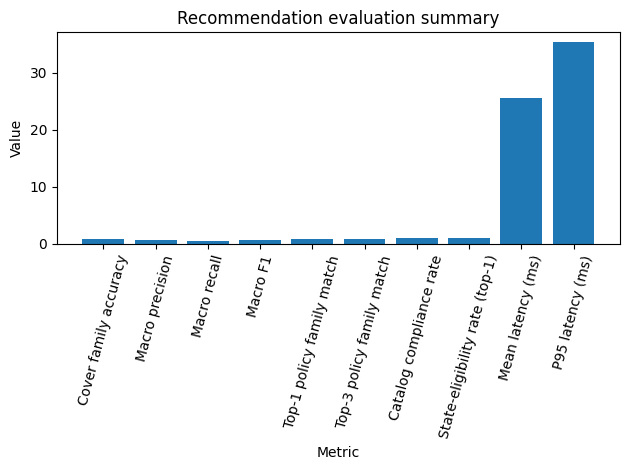

In [42]:
fig, ax = plt.subplots()
ax.bar(recommendation_summary["Metric"], recommendation_summary["Value"])
ax.set_title("Recommendation evaluation summary")
ax.set_ylabel("Value")
ax.set_xlabel("Metric")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

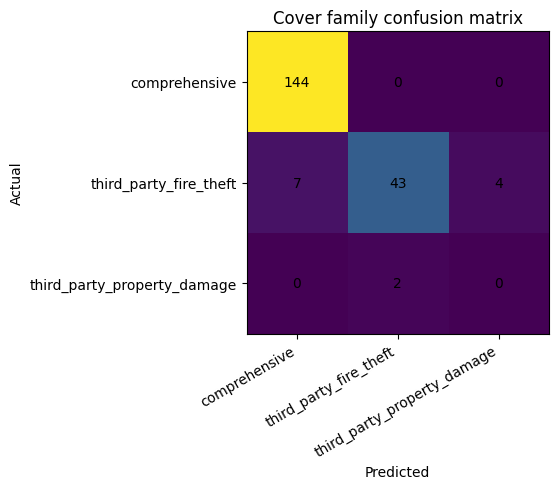

In [43]:
labels = sorted(recommendation_eval["true_cover_family"].dropna().unique())
cm = confusion_matrix(
    recommendation_eval["true_cover_family"],
    recommendation_eval["pred_cover_family"],
    labels=labels,
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm)
ax.set_title("Cover family confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticklabels(labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

## 11. Manual review and safety fallback

This section checks what happens when the user profile is incomplete.

What the output means:
- profiles with missing required fields should not be forced through the model
- the system should return a manual review status instead
- this is an important safety and product requirement

In [44]:
# Check whether incomplete profiles are sent to manual review instead of forcing a recommendation.

incomplete_profiles = [
    {"age": 28, "state": "NSW", "vehicle_value": 25000, "annual_km": 12000, "claims_last_5y": 0, "vehicle_type": "sedan"},
    {"age": 41, "state": "VIC", "vehicle_year": 2019, "annual_km": 10000, "claims_last_5y": 1, "vehicle_type": "suv", "usage_type": "private"},
    {"age": 23, "vehicle_year": 2018, "vehicle_value": 18000, "annual_km": 16000, "claims_last_5y": 2, "vehicle_type": "hatch", "usage_type": "commute"},
]

manual_review_results = []
for profile in incomplete_profiles:
    result = run_advisor_pipeline(profile)
    manual_review_results.append(
        {
            "profile": str(profile),
            "status": result["status"],
            "missing_fields": ", ".join(result.get("missing_fields", [])),
        }
    )

manual_review_df = pd.DataFrame(manual_review_results)
manual_review_df

,profile,status,missing_fields
0,"{'age': 28, 'state': 'NSW', 'vehicle_value': 2...",manual_review,"vehicle_year, usage_type"
1,"{'age': 41, 'state': 'VIC', 'vehicle_year': 20...",manual_review,vehicle_value
2,"{'age': 23, 'vehicle_year': 2018, 'vehicle_val...",manual_review,state


## 12. Parameters used in the evaluation

This summary makes the model and evaluation setup easy to explain in the demo.

What the output shows:
- the main modelling choices
- key dataset settings
- selected model types
- practical reasons behind those choices

This is useful when explaining why the team chose a simple and stable baseline for Sprint 1.

In [45]:
# Summarise the main modelling and evaluation parameters used in this notebook.

parameter_summary = pd.DataFrame([
    {
        "Area": "Synthetic dataset",
        "Parameters": "n=3000, seed=42",
        "Reason": "Enough rows for stable evaluation while still quick in Colab",
    },
    {
        "Area": "Train/test split",
        "Parameters": "test_size=0.20, random_state=42, stratify by cover family",
        "Reason": "Stable holdout evaluation with balanced recommendation classes",
    },
    {
        "Area": "Random Forest",
        "Parameters": "n_estimators=180, min_samples_leaf=3, random_state=42",
        "Reason": "Good non-linear baseline without making runtime too heavy",
    },
    {
        "Area": "Gradient Boosting",
        "Parameters": "n_estimators=180, learning_rate=0.05, max_depth=3",
        "Reason": "Strong structured-data benchmark with controlled complexity",
    },
    {
        "Area": "Linear Regression",
        "Parameters": "default settings",
        "Reason": "Fast interpretable baseline and useful benchmark for Sprint 1",
    },
    {
        "Area": "Recommendation evaluation sample",
        "Parameters": "up to 200 holdout cases",
        "Reason": "Enough for demo charts and latency measurement without slowing the notebook",
    },
])

parameter_summary

,Area,Parameters,Reason
0,Synthetic dataset,"n=3000, seed=42",Enough rows for stable evaluation while still ...
1,Train/test split,"test_size=0.20, random_state=42, stratify by c...",Stable holdout evaluation with balanced recomm...
2,Random Forest,"n_estimators=180, min_samples_leaf=3, random_s...",Good non-linear baseline without making runtim...
3,Gradient Boosting,"n_estimators=180, learning_rate=0.05, max_depth=3",Strong structured-data benchmark with controll...
4,Linear Regression,default settings,Fast interpretable baseline and useful benchma...
5,Recommendation evaluation sample,up to 200 holdout cases,Enough for demo charts and latency measurement...


## 13. Optional LLM explanation evaluation

This section measures the optional LLM-based explanation layer.

What is measured:
- response latency
- prompt, completion, and total token counts
- estimated cost if pricing is provided

What the output means:
- it shows whether the explanation layer is usable in real time
- it also helps estimate operating cost for future versions

In [47]:
# Install dependencies for LLM-based explanations
# In Colab, run this cell once.
!pip -q install groq langchain-groq langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.1 MB/s eta 0:00:00


In [48]:
# Evaluate the optional LLM explanation layer.
# The API key is read from the environment so it is not stored in the notebook.

RUN_LLM_EVAL = True
LLM_MODEL_NAME = "llama-3.1-8b-instant"
os.environ["GROQ_API_KEY"] = "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"

# Set pricing only if you want a rough cost estimate.
INPUT_COST_PER_MILLION = 0.0
OUTPUT_COST_PER_MILLION = 0.0

def build_llm_prompt(profile: dict, result: dict) -> str:
    top_recs = result["recommendations"][["Insurer", "Product Name", "Cover Family", "Estimated Premium", "Fit Score"]]
    return f"""
You are an insurance recommendation explainer.

User profile:
{profile}

Predicted risk score: {result['risk_score']}
Predicted portfolio premium estimate: {result['portfolio_premium_estimate']}
Recommended cover family: {result['recommended_cover_family']}

Top recommendations:
{top_recs.to_string(index=False)}

Write a short, clear explanation for why the top recommendation is suitable.
Keep it easy to understand and grounded in the provided facts.
""".strip()

def evaluate_llm_explanations(sample_cases, model_name=LLM_MODEL_NAME):
    api_key = os.getenv("GROQ_API_KEY")
    if not api_key:
        print("No GROQ_API_KEY found. LLM evaluation will be skipped.")
        return pd.DataFrame()

    try:
        from groq import Groq
    except Exception as exc:
        print("The groq package is not available. Install it first if you want live LLM evaluation.")
        print("Error:", exc)
        return pd.DataFrame()

    client = Groq(api_key=api_key)
    rows = []

    for idx, profile in enumerate(sample_cases, start=1):
        result = run_advisor_pipeline(profile)
        if result["status"] != "ok":
            continue

        prompt = build_llm_prompt(profile, result)

        start = time.perf_counter()
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": "You explain insurance recommendations clearly and safely."},
                {"role": "user", "content": prompt},
            ],
            temperature=0.2,
            max_tokens=220,
        )
        latency_ms = (time.perf_counter() - start) * 1000

        usage = getattr(response, "usage", None)
        prompt_tokens = getattr(usage, "prompt_tokens", None) if usage else None
        completion_tokens = getattr(usage, "completion_tokens", None) if usage else None
        total_tokens = getattr(usage, "total_tokens", None) if usage else None

        input_cost = 0.0 if prompt_tokens is None else (prompt_tokens / 1_000_000) * INPUT_COST_PER_MILLION
        output_cost = 0.0 if completion_tokens is None else (completion_tokens / 1_000_000) * OUTPUT_COST_PER_MILLION

        message = response.choices[0].message.content.strip()

        rows.append(
            {
                "case_id": idx,
                "latency_ms": latency_ms,
                "prompt_tokens": prompt_tokens,
                "completion_tokens": completion_tokens,
                "total_tokens": total_tokens,
                "estimated_cost": input_cost + output_cost,
                "preview": message[:200],
            }
        )

    return pd.DataFrame(rows)

sample_cases = [row.to_dict() for _, row in X_test.head(5).iterrows()]
llm_eval_df = evaluate_llm_explanations(sample_cases) if RUN_LLM_EVAL else pd.DataFrame()

if not RUN_LLM_EVAL:
    print("LLM evaluation is disabled because no GROQ_API_KEY was found in the environment.")

,Metric,Value
0,Mean latency (ms),617.515183
1,P95 latency (ms),704.088951
2,Mean prompt tokens,356.600000
3,Mean completion tokens,217.200000
4,Mean total tokens,573.800000
5,Estimated total cost,0.000000


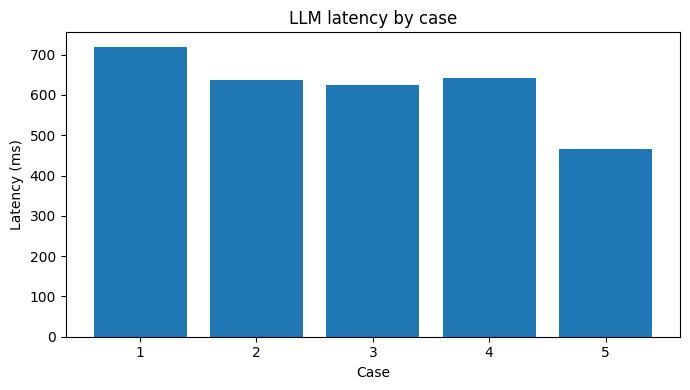

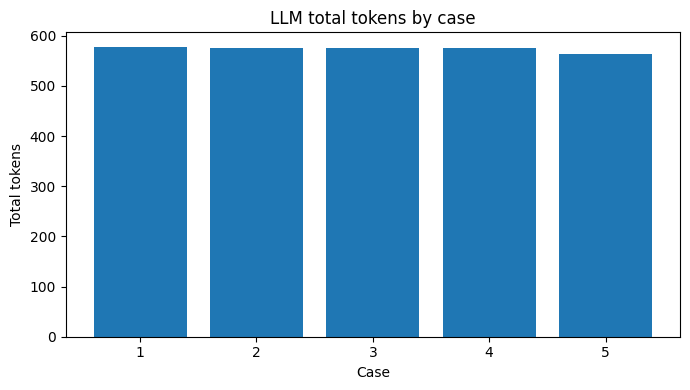

In [49]:
# Summarise LLM latency, token usage, and estimated cost if live LLM evaluation was run.

if not llm_eval_df.empty:
    llm_summary = pd.DataFrame([
        {"Metric": "Mean latency (ms)", "Value": llm_eval_df["latency_ms"].mean()},
        {"Metric": "P95 latency (ms)", "Value": llm_eval_df["latency_ms"].quantile(0.95)},
        {"Metric": "Mean prompt tokens", "Value": llm_eval_df["prompt_tokens"].mean()},
        {"Metric": "Mean completion tokens", "Value": llm_eval_df["completion_tokens"].mean()},
        {"Metric": "Mean total tokens", "Value": llm_eval_df["total_tokens"].mean()},
        {"Metric": "Estimated total cost", "Value": llm_eval_df["estimated_cost"].sum()},
    ])
    display(llm_summary)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(llm_eval_df["case_id"].astype(str), llm_eval_df["latency_ms"])
    ax.set_title("LLM latency by case")
    ax.set_xlabel("Case")
    ax.set_ylabel("Latency (ms)")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(llm_eval_df["case_id"].astype(str), llm_eval_df["total_tokens"])
    ax.set_title("LLM total tokens by case")
    ax.set_xlabel("Case")
    ax.set_ylabel("Total tokens")
    plt.tight_layout()
    plt.show()
else:
    print("LLM evaluation was not run. Add GROQ_API_KEY to the environment if you want live LLM metrics.")

## 14. Additional demo visuals

These charts strengthen the demo by showing the system from a business point of view.

This section adds:
- premium error-band visuals
- recommendation quality versus a naive baseline
- risk-to-premium consistency
- recommendation confidence and segment analysis

What the outputs mean:
- the premium charts show whether errors stay within practical ranges
- the recommendation charts show whether the shortlist is better than chance
- the consistency chart shows whether higher risk is associated with higher premium
- the final recommendation section highlights where the system is strong or weak

,Error Band,Share of cases
0,Within $50,28.00%
1,Within $100,46.83%
2,Within $150,67.67%
3,Within $200,80.67%
4,Within $300,95.67%
5,Within $400,99.17%
6,Within $500,100.00%


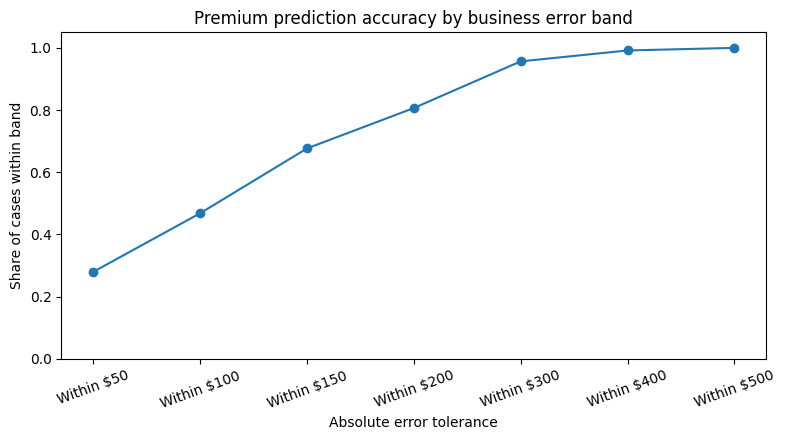

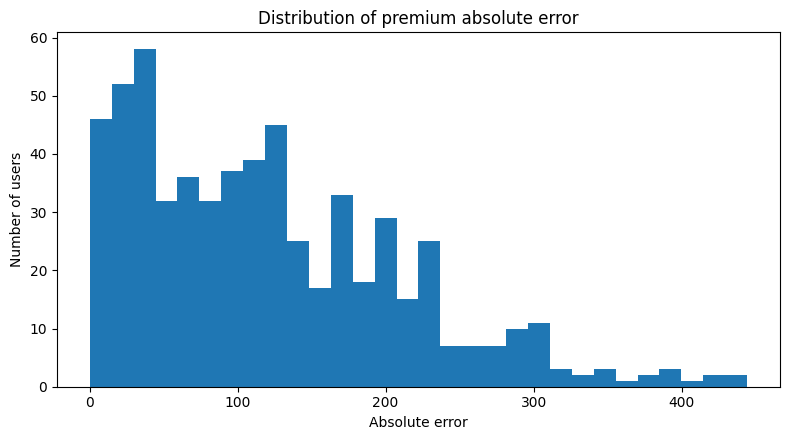

,Metric,Value
0,Premium MAE,120.8341
1,Premium Median AE,106.7112
2,Premium P90 AE,238.8156
3,Share within $100,0.4683
4,Share within $200,0.8067
5,Share within $300,0.9567


In [50]:
# Analyse premium prediction error using business-friendly error bands.

premium_abs_error = np.abs(y_premium_test - premium_pred)
premium_error_df = pd.DataFrame({
    "actual_premium": y_premium_test.values,
    "predicted_premium": premium_pred,
    "absolute_error": premium_abs_error,
})

error_thresholds = [50, 100, 150, 200, 300, 400, 500]
premium_band_accuracy = pd.DataFrame({
    "Error Band": [f"Within ${x}" for x in error_thresholds],
    "Share of cases": [(premium_error_df["absolute_error"] <= x).mean() for x in error_thresholds],
})

display(premium_band_accuracy.style.format({"Share of cases": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(premium_band_accuracy["Error Band"], premium_band_accuracy["Share of cases"], marker="o")
ax.set_title("Premium prediction accuracy by business error band")
ax.set_xlabel("Absolute error tolerance")
ax.set_ylabel("Share of cases within band")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(premium_error_df["absolute_error"], bins=30)
ax.set_title("Distribution of premium absolute error")
ax.set_xlabel("Absolute error")
ax.set_ylabel("Number of users")
plt.tight_layout()
plt.show()

premium_band_summary = pd.DataFrame([
    {"Metric": "Premium MAE", "Value": premium_abs_error.mean()},
    {"Metric": "Premium Median AE", "Value": np.median(premium_abs_error)},
    {"Metric": "Premium P90 AE", "Value": np.quantile(premium_abs_error, 0.90)},
    {"Metric": "Share within $100", "Value": (premium_abs_error <= 100).mean()},
    {"Metric": "Share within $200", "Value": (premium_abs_error <= 200).mean()},
    {"Metric": "Share within $300", "Value": (premium_abs_error <= 300).mean()},
])

display(premium_band_summary.style.format({"Value": "{:.4f}"}))

,Metric,Model shortlist,Random shortlist baseline
0,Top-1 accuracy,93.00%,25.00%
1,Top-3 accuracy,93.50%,75.00%
2,Catalog-only validity,100.00%,100.00%
3,State-eligible top-1,100.00%,nan%


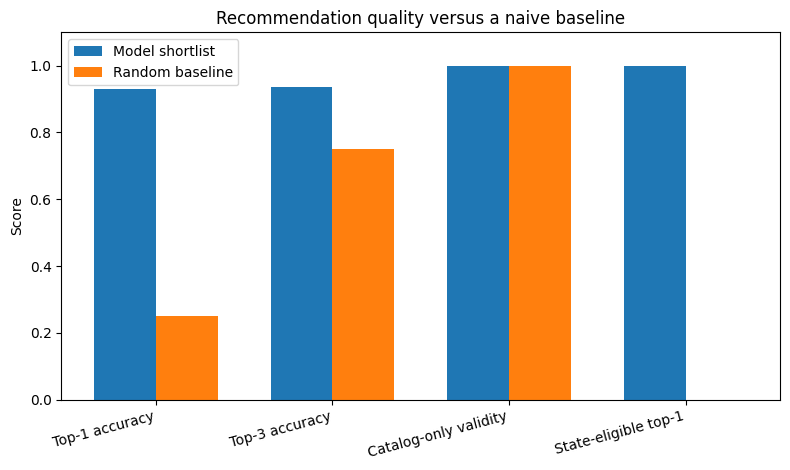

,Cover Family,top1_family_match,top3_family_match
0,comprehensive,100.00%,100.00%
1,third_party_fire_theft,77.78%,79.63%
2,third_party_property_damage,0.00%,0.00%


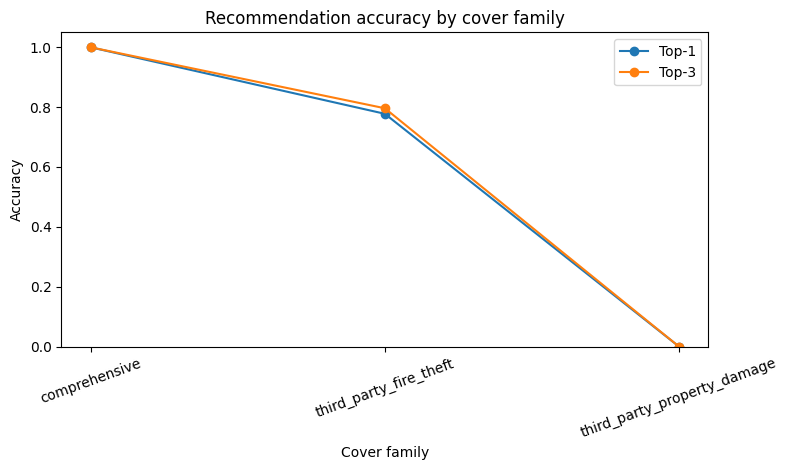

In [51]:
# Compare recommendation quality with a simple random baseline and inspect performance by cover family.

observed_cover_families = sorted(policy_catalog["Cover Family"].dropna().unique())
random_top1_baseline = 1 / max(1, len(observed_cover_families))
random_top3_baseline = min(3, len(observed_cover_families)) / max(1, len(observed_cover_families))

recommendation_benchmark = pd.DataFrame([
    {"Metric": "Top-1 accuracy", "Model shortlist": recommendation_eval["top1_family_match"].mean(), "Random shortlist baseline": random_top1_baseline},
    {"Metric": "Top-3 accuracy", "Model shortlist": recommendation_eval["top3_family_match"].mean(), "Random shortlist baseline": random_top3_baseline},
    {"Metric": "Catalog-only validity", "Model shortlist": recommendation_eval["catalog_only"].mean(), "Random shortlist baseline": 1.0},
    {"Metric": "State-eligible top-1", "Model shortlist": recommendation_eval["state_eligible_top1"].mean(), "Random shortlist baseline": np.nan},
])

display(recommendation_benchmark.style.format({"Model shortlist": "{:.2%}", "Random shortlist baseline": "{:.2%}"}))

x = np.arange(len(recommendation_benchmark))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x - width / 2, recommendation_benchmark["Model shortlist"], width=width, label="Model shortlist")
ax.bar(x + width / 2, recommendation_benchmark["Random shortlist baseline"].fillna(0), width=width, label="Random baseline")
ax.set_xticks(x)
ax.set_xticklabels(recommendation_benchmark["Metric"], rotation=15, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Recommendation quality versus a naive baseline")
ax.legend()
plt.tight_layout()
plt.show()

cover_perf = (
    recommendation_eval.groupby("true_cover_family")[["top1_family_match", "top3_family_match"]]
    .mean()
    .reset_index()
    .rename(columns={"true_cover_family": "Cover Family"})
)

display(cover_perf.style.format({"top1_family_match": "{:.2%}", "top3_family_match": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(cover_perf["Cover Family"], cover_perf["top1_family_match"], marker="o", label="Top-1")
ax.plot(cover_perf["Cover Family"], cover_perf["top3_family_match"], marker="o", label="Top-3")
ax.set_title("Recommendation accuracy by cover family")
ax.set_xlabel("Cover family")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

,avg_predicted_risk,avg_predicted_premium,avg_actual_premium,n
0,25.15,793.45,849.80,60
1,30.87,999.49,973.58,60
2,34.13,1093.03,1068.39,60
3,37.15,1148.86,1179.07,60
4,40.06,1198.46,1195.70,60
5,43.00,1352.98,1358.65,60
6,46.57,1460.79,1442.57,60
7,50.92,1465.73,1446.35,60
8,56.90,1487.65,1452.85,60
9,70.41,1687.07,1711.84,60


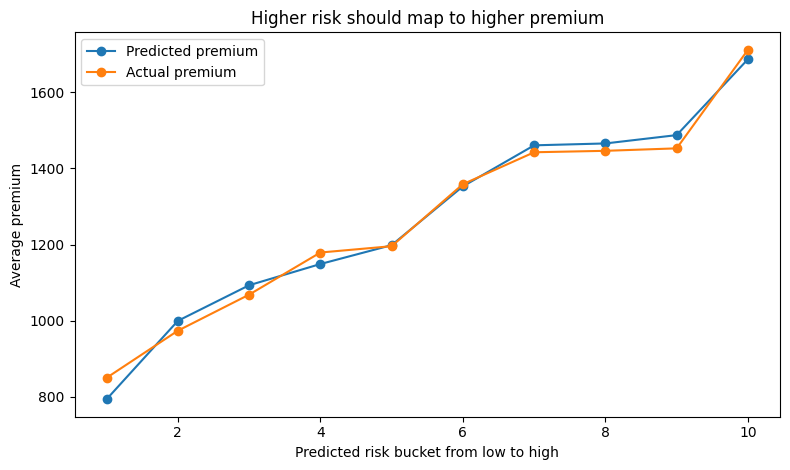

In [52]:
# Check whether higher predicted risk is associated with higher predicted and actual premiums.

calibration_df = pd.DataFrame({
    "predicted_risk": risk_pred,
    "predicted_premium": premium_pred,
    "actual_premium": y_premium_test.values,
})

calibration_df["risk_decile"] = pd.qcut(
    calibration_df["predicted_risk"],
    q=min(10, calibration_df["predicted_risk"].nunique()),
    duplicates="drop",
)

risk_premium_curve = (
    calibration_df.groupby("risk_decile")
    .agg(
        avg_predicted_risk=("predicted_risk", "mean"),
        avg_predicted_premium=("predicted_premium", "mean"),
        avg_actual_premium=("actual_premium", "mean"),
        n=("predicted_risk", "size"),
    )
    .reset_index(drop=True)
)

display(risk_premium_curve.style.format({
    "avg_predicted_risk": "{:.2f}",
    "avg_predicted_premium": "{:.2f}",
    "avg_actual_premium": "{:.2f}",
}))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(risk_premium_curve.index + 1, risk_premium_curve["avg_predicted_premium"], marker="o", label="Predicted premium")
ax.plot(risk_premium_curve.index + 1, risk_premium_curve["avg_actual_premium"], marker="o", label="Actual premium")
ax.set_title("Higher risk should map to higher premium")
ax.set_xlabel("Predicted risk bucket from low to high")
ax.set_ylabel("Average premium")
ax.legend()
plt.tight_layout()
plt.show()

Detailed recommendation rows: 200


,case_id,true_cover_family,recommended_cover_family,top1_policy,top1_family_match,top3_family_match,catalog_only,state_eligible_top1,confidence_margin,risk_score,portfolio_premium_estimate,age_band,risk_band,claims_last_5y
0,1,comprehensive,comprehensive,Allianz - Comprehensive Car Insurance,1,1,1,1,0.00,59.87,1527.52,25-34,Medium,1
1,2,comprehensive,comprehensive,Allianz - Comprehensive Car Insurance Essentials,1,1,1,1,0.00,42.82,1185.68,65+,Medium,0
2,3,comprehensive,comprehensive,CommBank - Comprehensive Saver Car Insurance,1,1,1,1,8.76,61.33,2479.19,35-49,Medium,0
3,4,comprehensive,comprehensive,Allianz - Comprehensive Car Insurance,1,1,1,1,0.00,60.03,1155.14,<25,Medium,1
4,5,comprehensive,comprehensive,Allianz - Comprehensive Car Insurance Essentials,1,1,1,1,0.00,45.06,1043.83,65+,Medium,1


,Metric,Value
0,Top-1 family accuracy,0.93000
1,Top-3 family accuracy,0.93500
2,Catalog-only validity,1.00000
3,State-eligible top-1,1.00000
4,Average confidence margin,2.42735


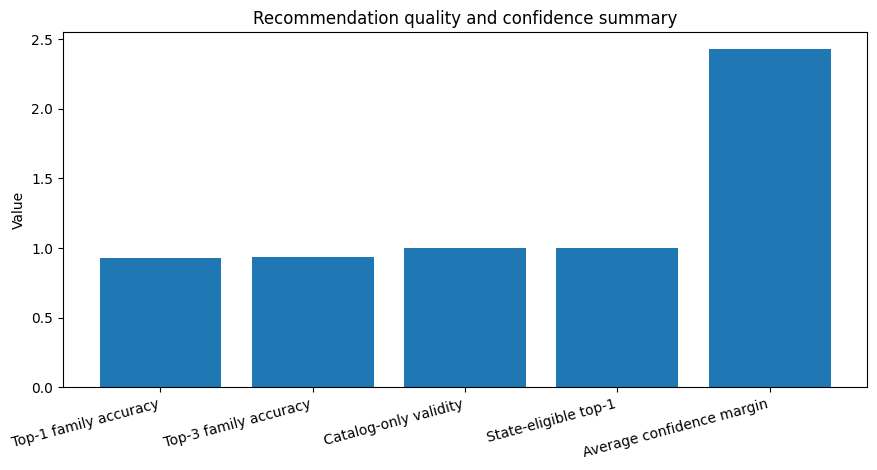

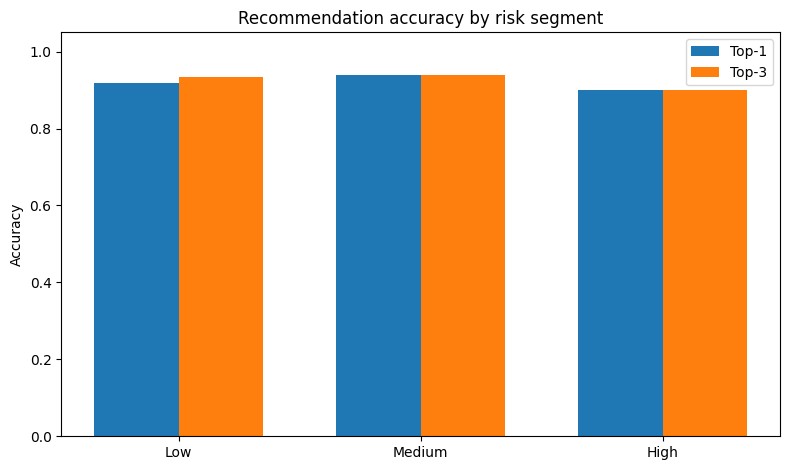

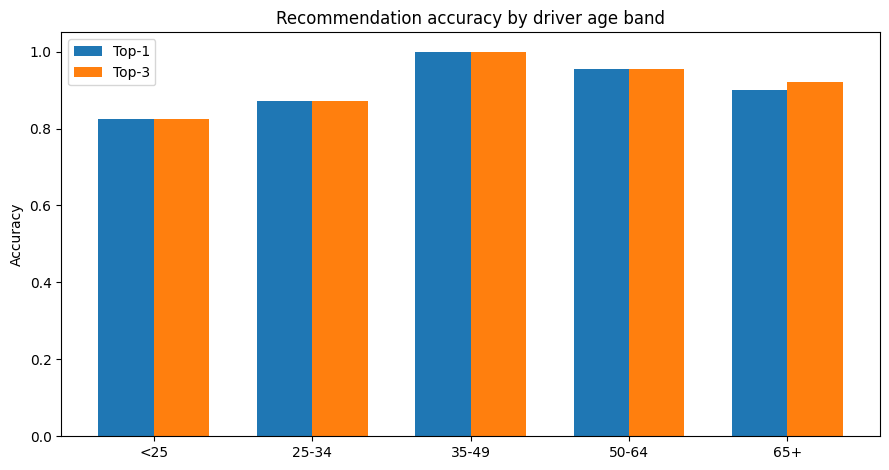

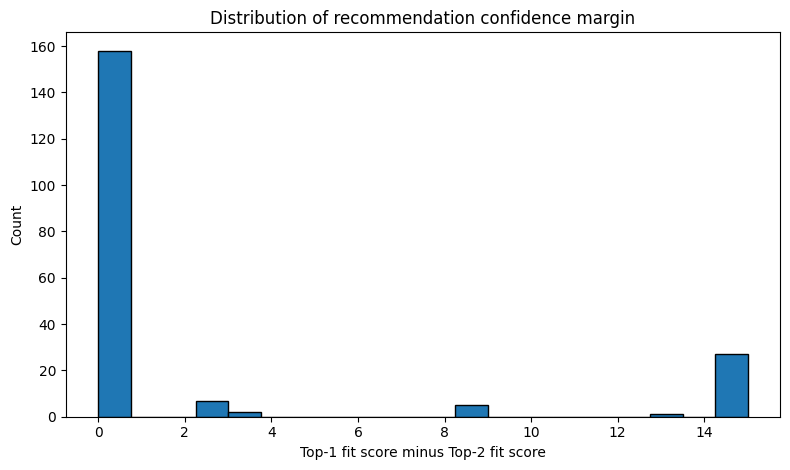

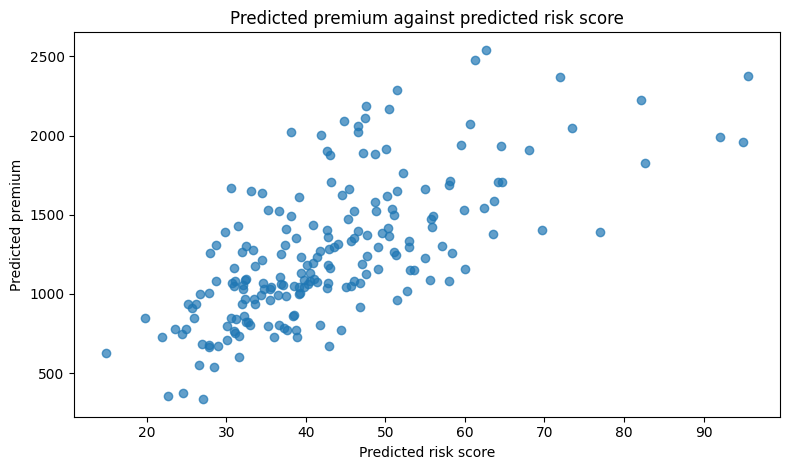

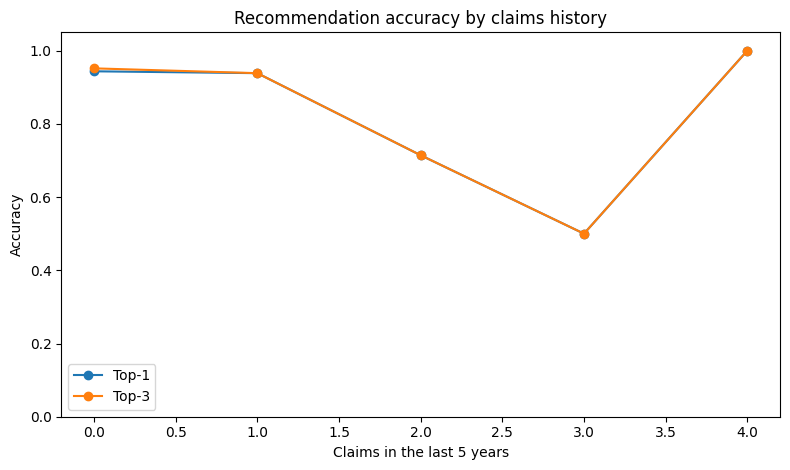

Best cases for the demo


,case_id,true_cover_family,recommended_cover_family,top1_policy,confidence_margin,risk_band,age_band,portfolio_premium_estimate
120,121,comprehensive,comprehensive,CommBank - Comprehensive Saver Car Insurance,15.0,Medium,35-49,1238.50
131,132,comprehensive,comprehensive,CommBank - Comprehensive Saver Car Insurance,15.0,Medium,35-49,1016.42
136,137,comprehensive,comprehensive,CommBank - Comprehensive Saver Car Insurance,15.0,Low,65+,848.77
7,8,comprehensive,comprehensive,CommBank - Comprehensive Saver Car Insurance,15.0,Medium,35-49,1077.04
11,12,comprehensive,comprehensive,CommBank - Comprehensive Saver Car Insurance,15.0,Medium,<25,1147.94


Weak cases for the demo


,case_id,true_cover_family,recommended_cover_family,top1_policy,confidence_margin,risk_band,age_band,portfolio_premium_estimate
6,7,third_party_fire_theft,comprehensive,Allianz - Comprehensive Car Insurance Essentials,0.0,Medium,25-34,1247.52
44,45,third_party_fire_theft,comprehensive,NRMA Insurance - Comprehensive Plus Car Insurance,0.0,Medium,<25,1256.66
50,51,third_party_fire_theft,comprehensive,NRMA Insurance - Comprehensive Plus Car Insurance,0.0,Medium,25-34,1936.61
52,53,third_party_fire_theft,comprehensive,Allianz - Comprehensive Car Insurance Essentials,0.0,Medium,65+,1035.71
88,89,third_party_property_damage,third_party_fire_theft,NRMA Insurance - Third Party Fire & Theft Car ...,0.0,Medium,50-64,1227.68


In [53]:
# Evaluate recommendation confidence and segment-level performance using the same held-out recommendation sample.

detail_rows = []

for idx, row in eval_sample.iterrows():
    profile = row[feature_cols].to_dict()
    result = run_advisor_pipeline(profile, top_k=3)

    if result["status"] != "ok":
        continue

    recs = result["recommendations"].reset_index(drop=True)

    top1_family = recs.loc[0, "Cover Family"] if len(recs) > 0 else None
    top3_families = recs["Cover Family"].head(3).tolist() if len(recs) > 0 else []
    top1_policy = f"{recs.loc[0, 'Insurer']} - {recs.loc[0, 'Product Name']}" if len(recs) > 0 else None

    top1_score = recs.loc[0, "Fit Score"] if len(recs) > 0 else np.nan
    top2_score = recs.loc[1, "Fit Score"] if len(recs) > 1 else np.nan
    confidence_margin = top1_score - top2_score if pd.notna(top1_score) and pd.notna(top2_score) else np.nan

    age_value = row.get("age", np.nan)
    if pd.notna(age_value):
        if age_value < 25:
            age_band = "<25"
        elif age_value < 35:
            age_band = "25-34"
        elif age_value < 50:
            age_band = "35-49"
        elif age_value < 65:
            age_band = "50-64"
        else:
            age_band = "65+"
    else:
        age_band = "Unknown"

    risk_value = result["risk_score"]
    if risk_value < 35:
        risk_band = "Low"
    elif risk_value < 65:
        risk_band = "Medium"
    else:
        risk_band = "High"

    detail_rows.append(
        {
            "case_id": idx + 1,
            "true_cover_family": row["true_cover_family"],
            "recommended_cover_family": result["recommended_cover_family"],
            "top1_policy": top1_policy,
            "top1_family_match": int(top1_family == row["true_cover_family"]),
            "top3_family_match": int(row["true_cover_family"] in top3_families),
            "catalog_only": int(set(recs["Policy ID"]).issubset(set(policy_catalog["Policy ID"]))),
            "state_eligible_top1": int(
                str(recs.loc[0, "State Specific"]).strip().lower() == "general"
                or str(recs.loc[0, "State Specific"]).strip().upper() == str(row["state"]).strip().upper()
            ),
            "confidence_margin": confidence_margin,
            "risk_score": result["risk_score"],
            "portfolio_premium_estimate": result["portfolio_premium_estimate"],
            "age_band": age_band,
            "risk_band": risk_band,
            "claims_last_5y": row.get("claims_last_5y", np.nan),
        }
    )

recommendation_detail_df = pd.DataFrame(detail_rows)

print(f"Detailed recommendation rows: {len(recommendation_detail_df)}")
display(recommendation_detail_df.head())

detail_summary = pd.DataFrame([
    {"Metric": "Top-1 family accuracy", "Value": recommendation_detail_df["top1_family_match"].mean()},
    {"Metric": "Top-3 family accuracy", "Value": recommendation_detail_df["top3_family_match"].mean()},
    {"Metric": "Catalog-only validity", "Value": recommendation_detail_df["catalog_only"].mean()},
    {"Metric": "State-eligible top-1", "Value": recommendation_detail_df["state_eligible_top1"].mean()},
    {"Metric": "Average confidence margin", "Value": recommendation_detail_df["confidence_margin"].mean()},
])

display(detail_summary)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(detail_summary["Metric"], detail_summary["Value"])
ax.set_title("Recommendation quality and confidence summary")
ax.set_ylabel("Value")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

risk_segment_perf = (
    recommendation_detail_df.groupby("risk_band")[["top1_family_match", "top3_family_match"]]
    .mean()
    .reindex(["Low", "Medium", "High"])
)

fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(risk_segment_perf.index))
width = 0.35
ax.bar(x - width / 2, risk_segment_perf["top1_family_match"], width=width, label="Top-1")
ax.bar(x + width / 2, risk_segment_perf["top3_family_match"], width=width, label="Top-3")
ax.set_xticks(x)
ax.set_xticklabels(risk_segment_perf.index)
ax.set_ylim(0, 1.05)
ax.set_title("Recommendation accuracy by risk segment")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

age_segment_perf = (
    recommendation_detail_df.groupby("age_band")[["top1_family_match", "top3_family_match"]]
    .mean()
    .reindex(["<25", "25-34", "35-49", "50-64", "65+"])
)

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(age_segment_perf.index))
ax.bar(x - width / 2, age_segment_perf["top1_family_match"], width=width, label="Top-1")
ax.bar(x + width / 2, age_segment_perf["top3_family_match"], width=width, label="Top-3")
ax.set_xticks(x)
ax.set_xticklabels(age_segment_perf.index)
ax.set_ylim(0, 1.05)
ax.set_title("Recommendation accuracy by driver age band")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(recommendation_detail_df["confidence_margin"].dropna(), bins=20, edgecolor="black")
ax.set_title("Distribution of recommendation confidence margin")
ax.set_xlabel("Top-1 fit score minus Top-2 fit score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(
    recommendation_detail_df["risk_score"],
    recommendation_detail_df["portfolio_premium_estimate"],
    alpha=0.7,
)
ax.set_title("Predicted premium against predicted risk score")
ax.set_xlabel("Predicted risk score")
ax.set_ylabel("Predicted premium")
plt.tight_layout()
plt.show()

claims_perf = (
    recommendation_detail_df.groupby("claims_last_5y")[["top1_family_match", "top3_family_match"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(claims_perf["claims_last_5y"], claims_perf["top1_family_match"], marker="o", label="Top-1")
ax.plot(claims_perf["claims_last_5y"], claims_perf["top3_family_match"], marker="o", label="Top-3")
ax.set_title("Recommendation accuracy by claims history")
ax.set_xlabel("Claims in the last 5 years")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

best_cases = recommendation_detail_df.sort_values(
    ["top1_family_match", "confidence_margin"], ascending=[False, False]
).head(5)

weak_cases = recommendation_detail_df.sort_values(
    ["top1_family_match", "confidence_margin"], ascending=[True, True]
).head(5)

print("Best cases for the demo")
display(best_cases[[
    "case_id",
    "true_cover_family",
    "recommended_cover_family",
    "top1_policy",
    "confidence_margin",
    "risk_band",
    "age_band",
    "portfolio_premium_estimate",
]])

print("Weak cases for the demo")
display(weak_cases[[
    "case_id",
    "true_cover_family",
    "recommended_cover_family",
    "top1_policy",
    "confidence_margin",
    "risk_band",
    "age_band",
    "portfolio_premium_estimate",
]])

## 15. Final interpretation

Suggested summary for the demo:

- the catalog is controlled and auditable
- the feature set is clearly defined
- the backend produces risk and premium predictions
- candidate models were compared before selection
- recommendation quality was tested with useful shortlist metrics
- manual review is triggered for incomplete profiles
- latency was measured for both the recommendation layer and the optional LLM layer

Overall, this notebook shows that Sprint 1 already has a working and measurable backend baseline.